In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [2]:
poll_data = pd.read_csv('pollution_cleaneddata.csv')

def split(x, y, train_ratio, random_seed):
    "Splits the data according to train_ratio % : (1-train_ration) % [train:test]. Assumes y is 1D"
    rng = np.random.default_rng(random_seed)
    idx = rng.permutation(len(y))
    
    x_randomized = x[idx]
    y_randomized = y[idx]

    ntrain = int(round(train_ratio*len(x)))
    xtrain, xtest = [x_randomized[:ntrain],x_randomized[ntrain:]] 
    ytrain, ytest = [y_randomized[:ntrain],y_randomized[ntrain:]]
    return xtrain, ytrain, xtest, ytest

### Polynomial Degree Selection

The `getDegree()` function determines which polynomial degree gives the best validation performance. First, the dataset is split into a **training set** and a **validation set** using the specified `train_ratio`. Randomness can be determined using the argument `random_seed`, where **None** is the default value. The function then tests polynomial degrees from `0` up to `max_degree`.

For each degree:
1. A polynomial is fitted to the **training data** using `np.polyfit()`.
2. The fitted polynomial is evaluated on both the training and validation data.
3. The **mean squared error (MSE)** is calculated on the validation set:
   $$   MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2 $$
4. The validation MSE is stored so that the different polynomial degrees can be compared. One can also choose to plot the interpolation functions and the MSE for the training and validation set.

Finally, the function returns the **polynomial degree with the lowest validation MSE**, along with the corresponding MSE. This allows the validation set to be used to select the polynomial complexity that performs best on unseen data.

In [3]:
def getDegree (x, y, max_degree = 2, plot= False, train_ratio = 0.8, random_seed = None):
    "Goes through different degrees of polynomial and returns the degree that gave the lowest MSE (mean squared error)"
    xrange = np.linspace(min(x), max(x), 1000)
    xtrain, ytrain, xval, yval = split(x,y,train_ratio, random_seed)
    degrees     = range(max_degree+1)
    MSEs        = np.zeros_like(degrees, dtype=float)
    if plot: 
        fig, (data,mse) = plt.subplots(2,1,figsize = (14,8))
        data.scatter(xval,yval,color='red',label='validation set')
        data.scatter(xtrain,ytrain,color='black',label='training data')
        data.set_xlabel("Temperature (F)")
        data.set_ylabel("Mortality Rate")
        data.grid(True)
    for p in degrees:
        coeffs = np.polyfit(xtrain, ytrain, deg = p)
        f_hat  = lambda x: np.polyval(coeffs, x)
        MSEs[p]= np.mean( (yval - f_hat(xval))**2 )
        if plot:
            data.plot(xrange,f_hat(xrange), label = f"Degree: {p}")
            mse.bar(p, MSEs[p] , color ='red', width =0.5, label = 'Validation MSE' if p==0 else None )
            mse.bar(p+0.2, np.mean( (ytrain - f_hat(xtrain))**2 ), color = 'black', width =0.5,
                    label = 'Training MSE' if p==0 else None )
    if plot:
        mse.legend()
        mse.set_ylabel("Mean Squared Error (MSE)")
        mse.set_xlabel("Degree")
        handles, labels = data.get_legend_handles_labels()
        fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.96), ncol=max_degree+1, frameon=False)      
        fig.suptitle( "Degree Selection based on MSE for dataset", fontsize=18, y=1.02)
        
    return np.argmin(MSEs) , min(MSEs)

Using the temperature as the regressor and the mortality rate as the response we see the different performances of varying ploynomial fits below. In this simulation, we set a fixed random seed to observe the proportion of training and validation datapoints. As we go along each line i.e. polynomial fit) we see that the training MSE decreases the more flexibility we add. However, this is not the case for the validation set where we see a case of overfitting after the optimal degree $(p=6)$.    

Flexibility: 6 | MSE: 4142.654368938037


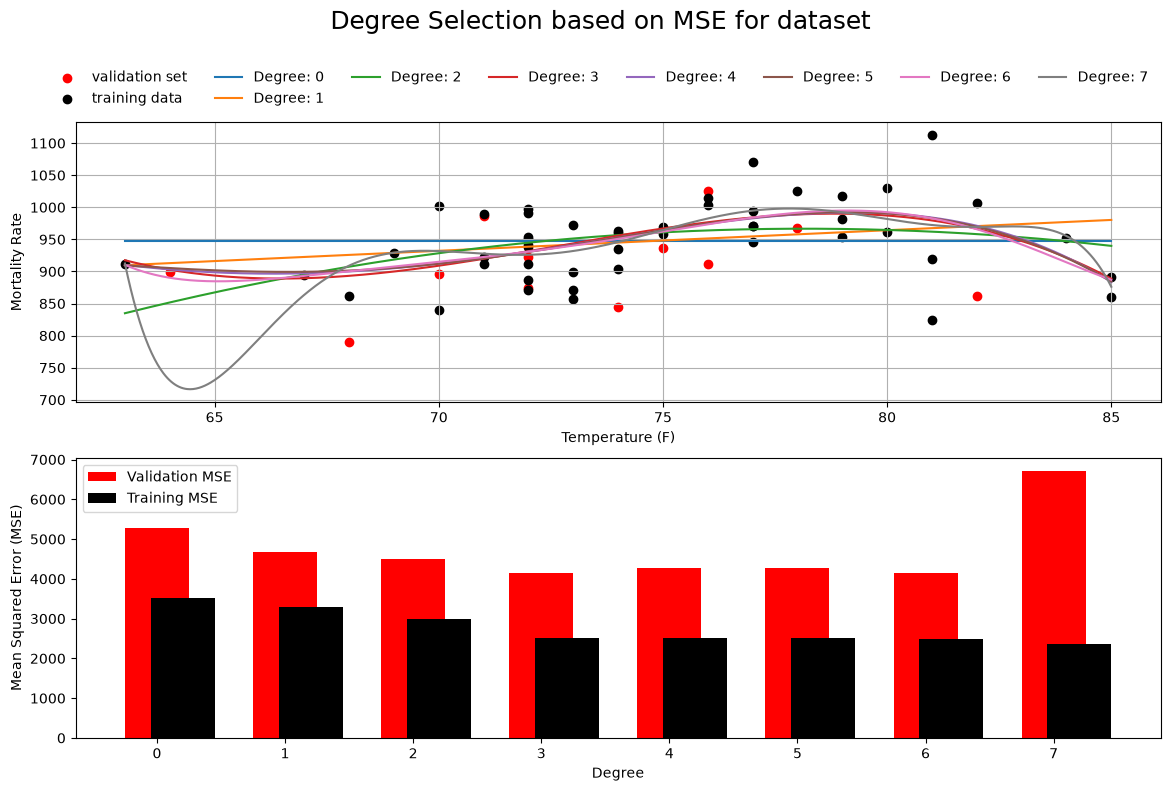

In [4]:
x = poll_data['JULT']
y = poll_data['MORT']

flexibility, MSE = getDegree (x, y, max_degree = 7, plot= True, train_ratio = 0.8, random_seed= 999)
print(f"Flexibility: {flexibility} | MSE: {MSE}")

Letting a loop run through different sets of (randomized) training and validation points, offers a clearer view of the problem of degree selection. Since the datapoints we used to train the model are assumed to be completely independent from the validation set, there is no guarantee that the trained model can capture the other datapoints well. Therefore, the performance is highly dependent on the selection of these two sets of datapoints.   

In [5]:
for _ in range(10):
    flexibility, MSE = getDegree (x, y, max_degree = 5, plot= False, train_ratio = 0.8)
    print(f"Flexibility: {flexibility} | MSE: {MSE}")

Flexibility: 3 | MSE: 5691.614121523099
Flexibility: 4 | MSE: 2023.8956890106365
Flexibility: 3 | MSE: 3831.7362336639276
Flexibility: 3 | MSE: 5083.0562651165355
Flexibility: 1 | MSE: 4972.438226265015
Flexibility: 3 | MSE: 3772.984218941832
Flexibility: 3 | MSE: 1444.116532299871
Flexibility: 3 | MSE: 3415.293685221784
Flexibility: 3 | MSE: 2800.6463558657147
Flexibility: 3 | MSE: 1860.7979495160898


Running the loop above will give varying results. This tells us that the validation set approach is not a good test measurement for model selection.

### K-Fold Cross-Validation

The `kfold_validate()` function evaluates how well a polynomial model of a specified degree generalizes to unseen data using **K-fold cross-validation**. First, the data is randomly shuffled then divided into `K` equally sized folds.

For each fold:

1. The current fold is used as the **validation set**, while all remaining folds are used as the **training set**.
2. A polynomial of the specified `poly_degree` is fitted to the training data using `np.polyfit()`.
3. The fitted polynomial is evaluated on the validation set.
4. The **mean squared error (MSE)** of the predictions on the validation set is calculated and stored.

This process is repeated `K` times so that every observation is used once as part of the validation set and `K-1` times as part of the training set. Finally, the function returns the **average validation MSE across all `K` folds**.

In [7]:
def kfold_validate(x, y, K, poly_degree, random_seed= None, plot=False):
    "Divides the data into k folds"
    rng = np.random.default_rng(random_seed)
    idx = rng.permutation(len(y))

    x_randomized = np.array(x[idx])
    y_randomized = np.array(y[idx])

    assert len(x)%K == 0 #Ensure that K will equally divide the data!
    cutoff = len(x)//K
    
    idx  = list(range(len(x)))
    kMSEs = np.zeros((K),dtype=float)
    for k in range(K):
        val_idx   = idx[k*cutoff:(k+1)*cutoff]
        train_idx = idx[:k*cutoff] + idx[(k+1)*cutoff:]
        
        xval   = x_randomized[val_idx]
        yval   = y_randomized[val_idx]
        xtrain = x_randomized[train_idx]
        ytrain = y_randomized[train_idx]
        
        coeffs = np.polyfit(xtrain, ytrain, deg = poly_degree)
        f_hat  = lambda x: np.polyval(coeffs, x)
        kMSEs[k]= np.mean( (yval - f_hat(xval))**2 )

    MSE = np.mean(kMSEs)
    return MSE

The main difference between Kfold verification and the previous method is that we can go through all of the data when testing the model. This gives us a less bias MSE. We begin by validating for a polynomial of degree 2.

In [8]:
x = poll_data['JULT']
y = poll_data['MORT']

flexibility = 2
Kfold       = 3

MSE = kfold_validate(x, y, Kfold, flexibility, random_seed = 999)

print(f"Flexibility: {flexibility} | MSE: {float(MSE)}")

Flexibility: 2 | MSE: 3714.920466169875


We now use this to verify the performances of different polynomial degrees. As seen below, the optimal degree is $p=3$ which does not coincide with the conclusions made in the validation set.  

In [21]:
x = poll_data['JULT']
y = poll_data['MORT']
Kfold = 3

for flexibility in range(10): 
    MSE = kfold_validate(x, y, Kfold, flexibility)
    print(f"Flexibility: {flexibility} | MSE: {float(MSE)}")

Flexibility: 0 | MSE: 3856.5745139795854
Flexibility: 1 | MSE: 3873.504535366899
Flexibility: 2 | MSE: 3497.9685178064215
Flexibility: 3 | MSE: 3469.912728579689
Flexibility: 4 | MSE: 3713.947622722648
Flexibility: 5 | MSE: 3130.886102446162
Flexibility: 6 | MSE: 4975.344170858094
Flexibility: 7 | MSE: 9006.32689353905
Flexibility: 8 | MSE: 7905.6360847535425
Flexibility: 9 | MSE: 30877.40168532185


### Parameter Uncertainty Using Bootstrap Sampling

The `parameter_uncertainty()` function estimates the **uncertainty of the parameters** in a log-linear Poisson regression model using **bootstrap sampling**. The model assumes that the expected value of \(y\) is related to \(x\) through:

$$
\lambda(x) = \exp(\beta_0 + \beta_1 x)
$$

The function performs the following steps:

1. The original dataset is used as the population from which bootstrap samples are drawn.
2. For each of the `B` bootstrap iterations, a new dataset of size \(n\) is created by **sampling with replacement**.
3. The Poisson max log-likelihood is calculated for the bootstrap sample:

$$
\ell(\beta_0,\beta_1)
=
\sum_i
\left[
-\exp(\beta_0+\beta_1x_i)
+
y_i(\beta_0+\beta_1x_i)
\right]
$$

After all `B` bootstrap iterations, the function returns the collection of estimated parameters. This produces a bootstrap distribution for both $beta_0$ and $\beta_1$, which can then be used to assess their **uncertainty**, for example by calculating confidence intervals or examining their distributions.

In [23]:
def parameter_uncertainty(x, y, B, plot=False):
    "Checks the 'confidence' interval of the parameters for a log-linear Poisson regression using bootsrap sampling"
    n     = len(y)
    idx   = list(range(n))
    betas = np.zeros((2,B))
    
    for b in range(B):
        boot_idx = np.random.choice(idx, size=n, replace=True)
        xtrain = x[boot_idx]
        ytrain = y[boot_idx]

        def Poisson_lmlikelihood (betas):
            b0, b1 = betas
            return np.sum( -np.exp( b0 + b1*xtrain ) + ytrain*(b0 + b1*xtrain) )

        opt_betas  = minimize( lambda betas: -Poisson_lmlikelihood(betas) , [0.0,0.0]).x
        betas[:,b] = opt_betas[:2]

    return betas

The function is used to give a distribution to the parameters as shown below.

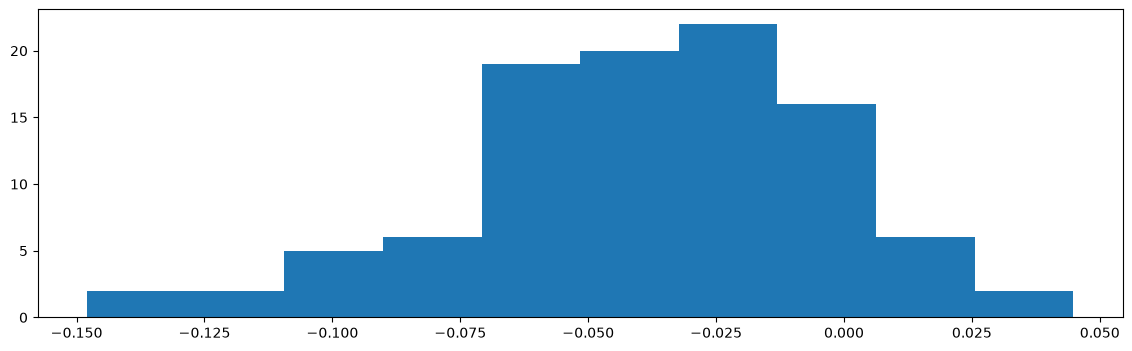

In [25]:
data = pd.read_csv("bird_count.csv")

#We reduce the years to avoid large values for exp(.). Remember to divide max(year) to B_1 since B0 + B1x = B0 + B1(year/max(year))!
year  = data['yr']/max(data['yr'])
count = data['count']

B = 100
betas    = parameter_uncertainty(year, count, B)

#Transform back!
betas[1] = betas[1]/max(data['yr'])

plt.figure(figsize=(14,4))
plt.hist(betas[1], bins=10);

In [27]:
print(f"β₀ = {np.mean(betas[0]):.3f} ± {np.std(betas[0]):.3f}")
print(f"β₁ = {np.mean(betas[1]):.3f} ± {np.std(betas[1]):.3f}")

β₀ = 79.241 ± 70.766
β₁ = -0.038 ± 0.035
